Ahora vamos con segmentación de los latidos

In [27]:
import os
import wfdb
import pandas as pd
import numpy as np

Para la segmentación de latidos usamos la base de datos QTDB 

In [28]:
data_folder = os.path.join("..","data")
qtdb_dir = os.path.join(data_folder, "qtdb_data")
os.makedirs(qtdb_dir, exist_ok=True)

if not os.listdir(qtdb_dir):
    print("Downloading the QTDB Database...")
    wfdb.dl_database('qtdb', dl_dir=qtdb_dir)
    print("Download completed.")
else: 
    print("Database already exists, skipping download.")

Database already exists, skipping download.


trabajamos con esta base de datos a 250hz teniendo 500 muestras por latido

In [29]:
record = wfdb.rdrecord("../data/qtdb_data/sel820")
print("Canales:", record.sig_name)
print("Frecuencia de muestreo:", record.fs)
print("Forma de la señal:", record.p_signal.shape)

# .q1c o .qt1 — anotaciones del anotador 1
ann = wfdb.rdann('../data/qtdb_data/sel820', 'q1c')

print("Símbolos:", ann.symbol)
print("Muestras:", ann.sample)
print("Aux notes:", ann.aux_note)

records = [f.replace('.hea', '') for f in os.listdir('../data/qtdb_data') if f.endswith('.hea')]
print(records)

Canales: ['ECG1', 'ECG2']
Frecuencia de muestreo: 250
Forma de la señal: (224999, 2)
Símbolos: ['(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N',

In [30]:
def wave_annotations(ann, signal_length):
    labels = np.zeros(signal_length)
    i = 0
    while i < len(ann.symbol):
        
        if ann.symbol[i] == '(':
            begin = ann.sample[i]

            if i + 1 < len(ann.symbol):
                next_symbol = ann.symbol[i + 1]

                if next_symbol == 'p':
                    wave_class = 1
                elif next_symbol == 'N':
                    wave_class = 2
                elif next_symbol == 't':
                    wave_class = 3
                else:
                    wave_class = 0

                j = i + 1
                while j < len(ann.symbol) and ann.symbol[j] != ')':
                    j += 1

                if ann.symbol[j] == ')':
                    end = ann.sample[j]
                    labels[begin:end] = wave_class
                i = j

        elif ann.symbol[i] == 't':
            begin = ann.sample[i]
            j = i + 1
            if j < len(ann.symbol) and ann.symbol[j] == ')':
                end = ann.sample[j]
                labels[begin:end] = 3  
            i = j

        i += 1

    return labels

labels = wave_annotations(ann, len(record.p_signal))
print(labels)

[0. 0. 0. ... 0. 0. 0.]


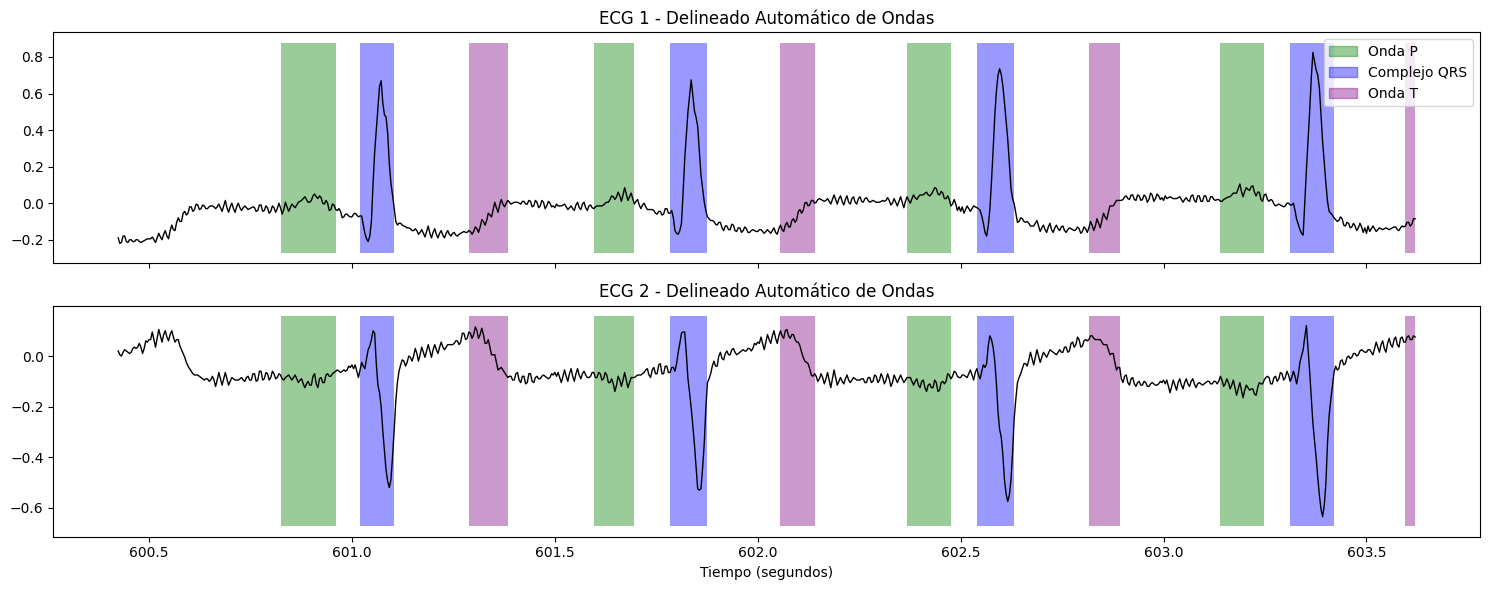

Clase 1 (P): 117
Clase 2 (QRS): 98
Clase 3 (T): 74


In [31]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 1. BUSCADOR AUTOMÁTICO DEL PRIMER LATIDO ANOTADO
# Buscamos dónde hay algún valor que no sea 0
indices_anotados = np.where(labels != 0)[0]
primer_indice_util = indices_anotados[0]

# Centramos nuestra ventana alrededor de ese latido 
# (ej: 200 puntos antes y 600 después para ver bien la onda)
inicio = primer_indice_util - 100
fin = primer_indice_util + 700

# 2. PREPARAR EL EJE DE TIEMPO
# (Asumimos que fs está definido, en QTDB suele ser 250)
tiempo = np.arange(inicio, fin) / 250

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 6), sharex=True)

ax1.plot(tiempo, record.p_signal[inicio:fin, 0], color='black', linewidth=1)
ax2.plot(tiempo, record.p_signal[inicio:fin, 1], color='black', linewidth=1)

# Forzamos que matplotlib calcule los límites reales ANTES de fill_between
fig.canvas.draw()

ymin1, ymax1 = ax1.get_ylim()
ymin2, ymax2 = ax2.get_ylim()

colores_clases = {
    1: ('green',  'Onda P'),
    2: ('blue',   'Complejo QRS'),
    3: ('purple', 'Onda T')
}

for clase, (color, nombre) in colores_clases.items():
    mascara = (labels[inicio:fin] == clase)
    ax1.fill_between(tiempo, ymin1, ymax1, where=mascara, facecolor=color, alpha=0.4)
    ax2.fill_between(tiempo, ymin2, ymax2, where=mascara, facecolor=color, alpha=0.4)

ax1.set_title('ECG 1 - Delineado Automático de Ondas')
ax2.set_title('ECG 2 - Delineado Automático de Ondas')
ax2.set_xlabel('Tiempo (segundos)')

leyenda = [Patch(color=color, alpha=0.4, label=nombre) 
           for clase, (color, nombre) in colores_clases.items()]
ax1.legend(handles=leyenda, loc='upper right')

plt.tight_layout()
plt.show()
ventana = labels[inicio:fin]
print("Clase 1 (P):", np.sum(ventana == 1))
print("Clase 2 (QRS):", np.sum(ventana == 2))
print("Clase 3 (T):", np.sum(ventana == 3))

In [6]:
def create_window(signal, label, window_size=500, step=250, ratio_silencio=0.10):
    X = []
    y = []

    for i in range(0, len(signal) - window_size + 1, step):
        x_window = signal[i : i + window_size]
        y_window = label[i : i + window_size]

        has_wave = np.any(y_window > 0)

        if has_wave: # onda P, QRS o T
            X.append(x_window)
            y.append(y_window)
        else: # es silencio (cogemos un porcentaje)
            if np.random.random() < ratio_silencio:
                X.append(x_window)
                y.append(y_window)

    return np.array(X), np.array(y)

In [7]:
def apply_z_score(X_windows):
    """
    Recibe un array de ventanas (n_ventanas, 500, 2)
    y normaliza cada una de forma independiente.
    """
    # Calculamos media y std para cada ventana y cada canal
    mean = np.mean(X_windows, axis=1, keepdims=True)
    std = np.std(X_windows, axis=1, keepdims=True) + 1e-8
    return (X_windows - mean) / std

In [8]:
from scipy.signal import butter, filtfilt

def filtrar_ecg(signal, fs=250):
    """
    Aplica un filtro Butterworth pasa-banda (0.5Hz - 45Hz) para limpiar la señal.
    """
    nyq = 0.5 * fs

    low = 0.5 / nyq
    high = 45.0 / nyq
    
    b, a = butter(4, [low, high], btype='band')
    
    signal_filtrada = np.zeros_like(signal)
    for ch in range(signal.shape[1]):
        signal_filtrada[:, ch] = filtfilt(b, a, signal[:, ch])
        
    return signal_filtrada

In [9]:
def process_patients(patients_list):
    dir = "../data/qtdb_data/"
    X, y = [], []

    for patient in patients_list:
        record = wfdb.rdrecord(dir + patient)
        fs = record.fs
        ann = wfdb.rdann(dir + patient, "q1c")
        signal_length = len(record.p_signal)

        labels = wave_annotations(ann, signal_length)
        signal_pura = filtrar_ecg(record.p_signal, fs=fs)
        
        X_w, y_w = create_window(signal_pura, labels)
        
        X_w = apply_z_score(X_w)

        X.append(X_w)
        y.append(y_w)

    X = np.concatenate(X, axis=0)
    y = np.concatenate(y, axis=0)
    
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    
    return X[indices], y[indices]

In [10]:
patients_train = [
    'sel100', 'sel102', 'sel103', 'sel104', 'sel114',
    'sel116', 'sel117', 'sel123', 'sel213', 'sel221',
    'sel223', 'sel230', 'sel301', 'sel302', 'sel306',
    'sel307', 'sel803', 'sel808', 'sel811', 'sel820',
    'sel821', 'sel840', 'sel847', 'sel853', 'sel871',
    'sel872', 'sel16265', 'sel16272', 'sel16273', 'sel16420',
    'sel16483', 'sel16539', 'sel16773', 'sel16786', 'sele0104',
    'sele0106', 'sele0107', 'sele0110', 'sele0111', 'sele0112',
    'sele0114', 'sele0116', 'sele0121', 'sele0122', 'sele0124',
    'sele0126', 'sele0129', 'sele0133', 'sele0136', 'sele0166',
    'sele0170', 'sele0203', 'sele0210', 'sele0211', 'sele0303',
    'sele0405', 'sele0406', 'sele0409', 'sele0411', 'sele0509',
    'sele0603', 'sel30', 'sel31', 'sel32', 'sel33', 
    'sel34', 'sel35', 'sel36', 'sel37', 'sel38',
    'sel39', 'sel40', 'sel41', 'sel42', 'sel43',
    'sel44', 'sel45', 'sel46', 'sel47', 'sel48',
    'sel14046', 'sel14157'
]

patients_test = [
    'sel231', 'sel232', 'sel233', 'sel308', 'sel310',
    'sel873', 'sel883', 'sel891', 'sel16795', 'sel17453', 
    'sele0604', 'sele0606', 'sele0607', 'sele0609', 'sele0612',
    'sele0704', 'sel49', 'sel50', 'sel51', 'sel52',
    'sel17152', 'sel14172', 'sel15814'
]

data_dir = "../data"
npy_dir = os.path.join(data_dir, "npy_data_qtdb")

if not os.path.exists(npy_dir):
    print("Creating npy_dir folder")
    os.makedirs(npy_dir)
    X_train, y_train = process_patients(patients_train)
    X_test, y_test = process_patients(patients_test)
    np.save(os.path.join(npy_dir, "X_train_QT.npy"), X_train)
    np.save(os.path.join(npy_dir, "y_train_QT.npy"), y_train)
    np.save(os.path.join(npy_dir, "X_test_QT.npy"),  X_test)
    np.save(os.path.join(npy_dir, "y_test_QT.npy"),  y_test)
    print("Data saved.")
else:
    print("Data already exists, loading from disk...")
    X_train = np.load(os.path.join(npy_dir, "X_train_QT.npy"))
    y_train = np.load(os.path.join(npy_dir, "y_train_QT.npy"))
    X_test  = np.load(os.path.join(npy_dir, "X_test_QT.npy"))
    y_test  = np.load(os.path.join(npy_dir, "y_test_QT.npy"))

Data already exists, loading from disk...


In [ ]:
'''
Esto cuando se pase a .py se puede quitar ya que se importará de forma directa (la función normalize)
'''
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, LSTM, Dense, RepeatVector, TimeDistributed, UpSampling1D, 
                                     Conv1DTranspose, Input, Bidirectional, concatenate, BatchNormalization, Dropout, SpatialDropout1D)
from tensorflow.keras.optimizers import Adam

'''
Modelo secuencial no es optimo ya que el kernel size es muy pequeño
model = Sequential()
model.add(Input(shape=(500, 2)))
model.add(Conv1D(filters=32, kernel_size=11, padding='same', activation='relu'))
model.add(Bidirectional(LSTM(64, return_sequences=True)))
model.add(Bidirectional(LSTM(32, return_sequences=True)))
model.add(TimeDistributed(Dense(32, activation='relu')))
model.add(TimeDistributed(Dense(4, activation='softmax')))
'''
#valores anteriores de las capas del lstm eran la mitad, 64 y 32
input_layer = Input(shape = (500, 2))

conv_low = Conv1D(filters = 16, kernel_size = 5, padding = "same", activation = "relu")(input_layer)
conv_mid = Conv1D(filters = 16, kernel_size = 15, padding = "same", activation = "relu")(input_layer)
conv_hi = Conv1D(filters = 16, kernel_size= 40, padding = "same", activation = "relu")(input_layer)
conv_total = concatenate([conv_low, conv_mid, conv_hi])

normalization_layer = BatchNormalization()(conv_total)
lstm_layer = Bidirectional(LSTM(64, return_sequences = True))(normalization_layer)
dropout_layer1 = SpatialDropout1D(0.2)(lstm_layer)
lstm_layer2 = Bidirectional(LSTM(32, return_sequences = True))(dropout_layer1)
dropout_layer2 = SpatialDropout1D(0.2)(lstm_layer2)
dense_layer = TimeDistributed(Dense(32, activation = "relu"))(dropout_layer2)

output_layer = TimeDistributed(Dense(4, activation = "softmax"))(dense_layer)

model = Model(inputs = input_layer, outputs = output_layer)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 500, 2)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 500, 16)   │        176 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 500, 16)   │        496 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 500, 16)   │      1,296 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 500, 48)   │          0 │ conv1d_9[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_10[0][0],  │
│                     │                   │            │ conv1d_11[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 48)   │        192 │ concatenate_3[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 500, 128)  │     57,856 │ batch_normalizat… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 500, 128)  │          0 │ bidirectional_3[… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 500, 64)   │     41,216 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_1 │ (None, 500, 64)   │          0 │ bidirectional_4[… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 500, 32)   │      2,080 │ spatial_dropout1… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 500, 4)    │        132 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 103,444 (404.08 KB)

 Trainable params: 103,348 (403.70 KB)

 Non-trainable params: 96 (384.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

TRAIN_MODEL = True  # cambiar a True para reentrenar

weights_map = {0: 0.1, 1: 15.0, 2: 20.0, 3: 25.0}
sample_weights = np.vectorize(weights_map.get)(y_train)

model.compile(
    optimizer=Adam(learning_rate=0.0001, clipnorm = 1.0), #lr demasiado alto, bajar a la mitad o probar con menos
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=6,
    min_lr=1e-6,
    verbose=1
)

model_save = ModelCheckpoint(
    filepath = "../models/labeling_v2_spatialdropout.keras",
    save_best_only = True,
    verbose = 1,
    monitor = "val_loss"
)

if TRAIN_MODEL:
    print("Starting training...")
    history = model.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=32,
        validation_data=(X_test, y_test),
        sample_weight=sample_weights,
        callbacks=[early_stop, reduce_lr, model_save]
    )

Starting training...
Epoch 1/50
2303/2303 ━━━━━━━━━━━━━━━━━━━━ 0s 984ms/step - accuracy: 0.4657 - loss: 0.1747
Epoch 1: val_loss improved from None to 0.93149, saving model to ../models/labeling_v2_spatialdropout.keras

Epoch 1: finished saving model to ../models/labeling_v2_spatialdropout.keras
2303/2303 ━━━━━━━━━━━━━━━━━━━━ 2468s 1s/step - accuracy: 0.4604 - loss: 0.1753 - val_accuracy: 0.4665 - val_loss: 0.9315 - learning_rate: 1.0000e-04
Epoch 2/50
2303/2303 ━━━━━━━━━━━━━━━━━━━━ 0s 977ms/step - accuracy: 0.4539 - loss: 0.1703
Epoch 2: val_loss did not improve from 0.93149
2303/2303 ━━━━━━━━━━━━━━━━━━━━ 2381s 1s/step - accuracy: 0.4538 - loss: 0.1724 - val_accuracy: 0.4361 - val_loss: 1.0396 - learning_rate: 1.0000e-04
Epoch 3/50
2303/2303 ━━━━━━━━━━━━━━━━━━━━ 0s 981ms/step - accuracy: 0.4549 - loss: 0.1720
Epoch 3: val_loss did not improve from 0.93149
2303/2303 ━━━━━━━━━━━━━━━━━━━━ 2391s 1s/step - accuracy: 0.4550 - loss: 0.1724 - val_accuracy: 0.4616 - val_loss: 0.9589 - learning

In [35]:
# Buscamos los índices que tienen las 3 ondas simultáneamente
indices_completos = []
for i in range(len(y_test)):
    clases = set(np.unique(y_test[i])) - {0}
    if len(clases) == 3:
        indices_completos.append(i)

print(f"Tienes {len(indices_completos)} ventanas para elegir.")
# Elegimos el primero de la lista para probar
indice_interesante = indices_completos[0] 
print(f"Probando con el índice: {indice_interesante}")

Tienes 707 ventanas para elegir.
Probando con el índice: 600


1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step


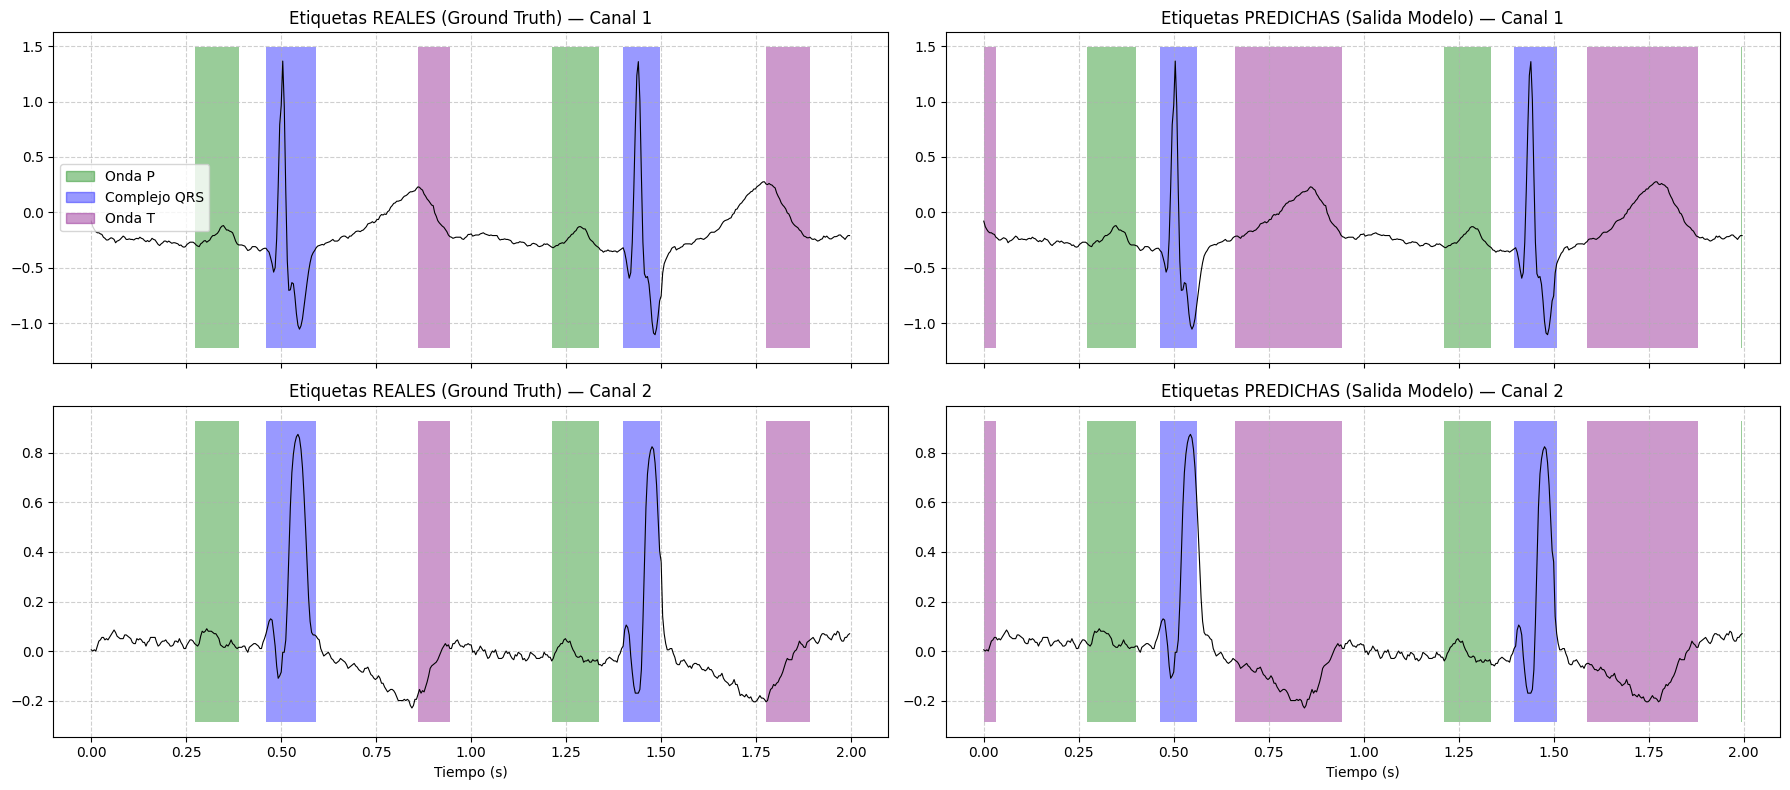

Accuracy en esta ventana: 0.7460
Clase 1 (P)  — Real:  62 | Pred:  67
Clase 2 (QRS)— Real:  59 | Pred:  54
Clase 3 (T)  — Real:  52 | Pred: 155
Clase 0 (BL) — Real: 327 | Pred: 224


In [ ]:
from tensorflow.keras.models import load_model

model = load_model("../models/labeling_v2_spatialdropout.keras", compile=False)

#el índice 601 tiene anotaciones reales
indice = 601

x_ventana = X_test[indice:indice+1]  # shape (1, 500, 2)

# Predecimos — salida shape (1, 500, 4) con probabilidades por clase
pred = model.predict(x_ventana)

# Cogemos la clase con   mayor probabilidad para cada muestra
pred_clases = np.argmax(pred[0], axis=-1)  # shape (500,)
y_real      = y_test[indice, :]         # shape (500,) — quitamos la dimensión extra

tiempo = np.arange(500) / 250  # eje de tiempo en segundos

colores_clases = {
    1: ('green',  'Onda P'),
    2: ('blue',   'Complejo QRS'),
    3: ('purple', 'Onda T')
}

fig, axes = plt.subplots(2, 2, figsize=(18, 8), sharex=True)

# Definimos los títulos base sin repetir el canal
titulos = [
    ('Etiquetas REALES (Ground Truth)', y_real,      axes[0, 0], axes[1, 0]),
    ('Etiquetas PREDICHAS (Salida Modelo)', pred_clases, axes[0, 1], axes[1, 1]),
]

for titulo, etiquetas, ax1, ax2 in titulos:
    ax1.plot(tiempo, X_test[indice][:, 0], color='black', linewidth=0.8)
    ax2.plot(tiempo, X_test[indice][:, 1], color='black', linewidth=0.8)

    fig.canvas.draw()
    ymin1, ymax1 = ax1.get_ylim()
    ymin2, ymax2 = ax2.get_ylim()

    for clase, (color, nombre) in colores_clases.items():
        mascara = (etiquetas == clase)
        ax1.fill_between(tiempo, ymin1, ymax1, where=mascara, facecolor=color, alpha=0.4)
        ax2.fill_between(tiempo, ymin2, ymax2, where=mascara, facecolor=color, alpha=0.4)

    # Títulos limpios y específicos por canal
    ax1.set_title(f'{titulo} — Canal 1')
    ax2.set_title(f'{titulo} — Canal 2')
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax2.grid(True, linestyle='--', alpha=0.6)

from matplotlib.patches import Patch
leyenda = [Patch(color=c, alpha=0.4, label=n) for _, (c, n) in colores_clases.items()]
axes[0, 0].legend(handles=leyenda)

axes[1, 0].set_xlabel('Tiempo (s)')
axes[1, 1].set_xlabel('Tiempo (s)')

plt.tight_layout()
plt.show()

# Métricas rápidas
print(f"Accuracy en esta ventana: {np.mean(pred_clases == y_real):.4f}")
print(f"Clase 1 (P)  — Real: {np.sum(y_real==1):3d} | Pred: {np.sum(pred_clases==1):3d}")
print(f"Clase 2 (QRS)— Real: {np.sum(y_real==2):3d} | Pred: {np.sum(pred_clases==2):3d}")
print(f"Clase 3 (T)  — Real: {np.sum(y_real==3):3d} | Pred: {np.sum(pred_clases==3):3d}")
print(f"Clase 0 (BL) — Real: {np.sum(y_real==0):3d} | Pred: {np.sum(pred_clases==0):3d}")